[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University, created by
[Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) drawing on a variety of
sources with some updates with Claude AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Efficient Computation for Multi-Dimensional Arrays using PyTorch and NumPy

This notebook covers the basics of PyTorch and its relationship with NumPy.  It includes most of the features you will need for this course.  The PyTorch tensor API is based on NumPy's array API, so we start with that.

## What is NumPy?

[NumPy](https://numpy.org/) (Numerical Python) is Python's library for numerical data, and provides a wealth of functionality for working with array data.

NumPy features include:
  * A fast and efficient **multidimensional array** object called the *ndarray*
  * Functions for performing **computations on arrays**
  * Tools for **reading and writing** array-based datasets to disk
  * Fast **linear algebra** operations and random number generation

This tutorial is a brief introduction.  For more information, please refer to one of the following resources:

* The NumPy [documentation](https://numpy.org/doc/stable/), which includes multiple tutorials.
* The [Python Data Science Handbook](https://github.com/jakevdp/PythonDataScienceHandbook) by Jake Vander Plas.

NumPy and PyTorch are going to be our primary Python programming tools for this course.  Overall, NumPy and related libraries are key tools used in machine learning.

As described in a recent [Nature publication](https://www.nature.com/articles/s41586-020-2649-2) by the authors and primary contributors to the package, NumPy has a special role in the Python data science and scientific computing eco-system:

> NumPy underpins almost every Python library that does scientific or numerical computation including SciPy, Matplotlib, pandas, scikit-learn, and scikit-image. ... Because of its inherent simplicity, the NumPy array is the de facto exchange format for array data in Python.

The following figure from this paper captures this:

<img style="float: center;" src="https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41586-020-2649-2/MediaObjects/41586_2020_2649_Fig2_HTML.png" width="400">

## From NumPy to PyTorch

Instead of NumPy's **n-d arrays**, PyTorch has **tensors**. But, as we will see, the PyTorch API is very similar to that provided by NumPy.   So once you know how to work with NumPy arrays, you know how to work with PyTorch tensors.

**Think of PyTorch tensors as “NumPy arrays with superpowers” — same syntax, but also aware of where they live (CPU/GPU) and how they were computed (autograd)**.

In addition, PyTorch is also a deep learning library, providing everything you need to experiment with this exciting tool.


Our first step is to **import** the package (note the "import as" shortcut):

In [1]:
import numpy as np
import torch

**Python note:**  Instead of the above import, we could have done ``from numpy import *``, which would have made every statement shorter by not having to write ``np.`` before each NumPy command.  That is not a good idea, as the NumPy namespace conflicts with built in Python functions like ``min`` or ``max``.

Arrays are the standard data containers in NumPy, and can have any number of dimensions.

Let's start with a one dimensional array:

In [2]:
my_array = np.array([1, 2, 3])
my_array

array([1, 2, 3])

And its pure Python counterpart:

In [3]:
my_list = [1, 2, 3]

Unlike NumPy arrays, Python lists can handle heterogeneous data types:

In [4]:
my_heterogeneous_list = [1, 2.0, True, 'Python', [1,2,3]]

# let's show the types of each element in the list:
[type(item) for item in my_heterogeneous_list]

[int, float, bool, str, list]

What have we gained over using a Python list?  In fact, NumPy arrays are less flexible than Python lists:

In [5]:
my_list[0] = 'a'

try :
    my_array[0] = 'a'
except :
    print("wrong type in assignment")

wrong type in assignment


As we just saw, Python lists are very flexible - they can store any type of data.  But that comes at a cost, both in speed and memory.
To understand this cost we need to understand the implementation of Python lists a little better.  Python is written in C, and under the hood, every Python object is essentialy pointer to a C structure.
Memory-wise, the Python list, is thus a pointer to a block of pointers, each of which in turn points to a Python object (even an integer is an object in Python).


![Array Memory Layout](https://github.com/jakevdp/PythonDataScienceHandbook/raw/master/notebooks/figures/array_vs_list.png)

The reduced flexibility of NumPy arrays comes with improved efficiency both in terms of storage, execution, and a wealth of functionality for fast manipulation of numeric data.

Furthermore, using NumPy's C API, libraries written in C or Fortran, can operate on the data stored in a NumPy array without needing to copy the data. 

Let's demonstrate the speed advantage of NumPy arrays:

In [6]:
my_array = np.arange(1000000)
my_list = list(range(1000000))
# Note: simply calling range(10000000) does not create a list!

In [7]:
my_array[:10]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [8]:
[1,2,3] * 3

[1, 2, 3, 1, 2, 3, 1, 2, 3]

In [9]:
%timeit my_array2 = my_array * 2

637 µs ± 40.7 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [10]:
%timeit my_list2 = [x * 2 for x in my_list]

26.8 ms ± 243 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


We can do the exact same thing in PyTorch:

In [11]:
my_array_pytorch = torch.arange(1000000)

In [12]:
%timeit my_array_pytorch2 = my_array_pytorch * 2

294 µs ± 1.68 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


This is our first example that demonstrates the speed advantage of using NumPy ndarrays over Python lists.

### Vectorized code

NumPy provides a high-level API for array programming.  If you can express your analysis as operations on vectors and matrices like we just did above, the resulting NumPy code will be fast, comparable in speed to code written in a compiled language.
To produce efficient NumPy code will require a different mindset:  we will need to think in terms of vectors and matrices.  This is often called **vectorization**, and refers to the process of expressing a computation in terms of vectors and matrices.
One of our goals in this course is to get you accustomed to expressing computations in this way.

**Why is vectorized code faster?**  By expressing our code in this way we are able to avoid for loops in our Python code.  Instead, the code performs the loop in the underlying C code layer, which is much faster.

**A note about timing Python code.**  There are multiple ways of timing Python code snippets in the Jupyter notebook;
``%time`` is another magic command that can be used for this task.  ``%timeit`` is usally preferred (see [this article](https://jakevdp.github.io/PythonDataScienceHandbook/01.07-timing-and-profiling.html) for more information about profiling Python code).

### Example of vectorized operations on NumPy ndarrays

NumPy ndarrays enable you to perform mathematical operations on entire arrays in a single operation without requiring for loops.  As mentioned above, this is called *vectorization*, and is key for writing efficient machine learning code.

We will now see some examples.

### Array multiplication and addition

In [13]:
data = np.array( [ [1,2,3], [4,5,6] ])
data

array([[1, 2, 3],
       [4, 5, 6]])

In [14]:
print(data * 10)    # multiply array by a scalar
print()
print(data + data)  # add arrays

[[10 20 30]
 [40 50 60]]

[[ 2  4  6]
 [ 8 10 12]]


### Boolean Operations on Arrays

You can also perform vectorized Boolean operations on arrays:

In [15]:
a1 = np.array([[1., 2., 3.], [4., 5., 6.]])
a2 = np.array([[0., 4., 1.], [7., 2., 12.]])
a2 > a1

array([[False,  True, False],
       [ True, False,  True]])

This works the same in PyTorch:

In [16]:
a1 = torch.tensor([[1., 2., 3.], [4., 5., 6.]])
a2 = torch.tensor([[0., 4., 1.], [7., 2., 12.]])
a2 > a1

tensor([[False,  True, False],
        [ True, False,  True]])

### Array shape and dtype

Every ndarray has a **shape**, which is a tuple indicating the size of each dimension, and a **dtype**, an object describing the data type of the array:


In [17]:
data.shape,data.dtype

((2, 3), dtype('int64'))

The `dtype` attribute tells us what kind of array got created.

Note that NumPy inferred the type from the data that we provided.  To demonstrate that, let's check what happens if there are floating point numbers in the input to the ndarray constructor:  

In [18]:
arr1 = np.array([6, 7.5, 8, 0, 1])
print(arr1,arr1.dtype)
arr2 = np.array([6, 7, 8, 0, 1])
print(arr2,arr2.dtype)

[6.  7.5 8.  0.  1. ] float64
[6 7 8 0 1] int64


Let's compare *shape* with the Python *len* function.  On 1d arrays the result is almost the same:

In [19]:
print(arr1.shape)
print(len(arr1))

(5,)
5


Now let's look at a 2d array:


In [20]:
print(data)
print("Its shape:")
print(data.shape)
print("Its length:")
print(len(data))

[[1 2 3]
 [4 5 6]]
Its shape:
(2, 3)
Its length:
2


### Data types

As described above, the dtype associated with an ndarray is the type used to store the elements of the array.
The numerical dtypes are named as follows: a type name, like float or int, followed by a number indicating the number of bits per element. A standard double-precision floating-point value (what’s used under the hood in Python’s float object) takes up 64 bits. Thus, this type is known in NumPy as ``float64``.

In [21]:
a1 = np.array([1, 2, 3], dtype=np.float64)
a2 = np.array([1, 2, 3], dtype=np.int32)
a1.dtype,a2.dtype

(dtype('float64'), dtype('int32'))

In [22]:
a1 = torch.tensor([1, 2, 3], dtype=torch.float64)
a2 = torch.tensor([1, 2, 3], dtype=torch.int32)
a1.dtype,a2.dtype

(torch.float64, torch.int32)

What would be the resulting data type for an array that contains strings and numbers?

In [23]:
# create an array that contains strings and 
# numbers and check its data type
a = np.array([1, 'python'])

In [24]:
a

array(['1', 'python'], dtype='<U21')

In [25]:
a = np.array([1.0, 2.0])
a.dtype

dtype('float64')

In [26]:
a = torch.tensor([1.0, 2.0])
a.dtype

torch.float32

What is the data type of the first element of the array?

### Creating arrays

NumPy has plenty of ways for creating all kinds of arrays - initialized with zeros, ones, or random values.  Typically they have a size argument that determines the shape of the array.

Here are some examples, and we'll start by creating an array of zeros:

In [27]:
np.zeros((2,3))

array([[0., 0., 0.],
       [0., 0., 0.]])

In [28]:
torch.zeros((2,3))

tensor([[0., 0., 0.],
        [0., 0., 0.]])

An array of ones:

In [29]:
np.ones((2,3))

array([[1., 1., 1.],
       [1., 1., 1.]])

In [30]:
torch.ones((2,3))

tensor([[1., 1., 1.],
        [1., 1., 1.]])

### Arrays of random numbers

Random numbers are everywhere in machine learning: initializing the weights of
a network, shuffling a training set, splitting data, drawing a minibatch.  We
will use PyTorch's generators, since PyTorch is going to be our tool for the rest of the course.

Random integers, ten rolls of a die:

In [31]:
torch.randint(1, 7, size=(10,))

tensor([4, 1, 4, 3, 5, 6, 3, 4, 6, 1])

Run that cell again and you get a different list of numbers.  That is usually what you
want, and occasionally a disaster: a result you cannot reproduce is a result
you cannot debug.

Every call above uses a global random number generator that PyTorch keeps
for you.  **Seeding** it puts that generator into a known state, so the next
draws are fixed:

In [32]:
torch.manual_seed(42)
print(torch.randint(1, 7, size=(10,)))
print(torch.randint(1, 7, size=(10,)))     # different numbers: the generator moved on

torch.manual_seed(42)                      # back to the same state
print(torch.randint(1, 7, size=(10,)))     # the first line again

tensor([1, 6, 5, 5, 1, 6, 5, 3, 5, 6])
tensor([5, 5, 3, 1, 4, 5, 6, 2, 4, 5])
tensor([1, 6, 5, 5, 1, 6, 5, 3, 5, 6])


Two things to take from that.  Reseeding rewinds the generator, and *not*
reseeding lets it run on — the second line differs from the first because the
generator advanced when it produced the first.  Seeded numbers are still
perfectly good random numbers; they are simply the same ones every time you run
the notebook.

**The convention in this course.**  Notebooks call `torch.manual_seed(0)` once,
near the top, so that every figure and number you see is the one you will get.
When a particular experiment needs its own reproducible stream — one that is
not disturbed by however many random numbers other cells happen to draw — we
create a *local* generator and pass it in:

In [33]:
generator = torch.Generator().manual_seed(0)
print(torch.randint(1, 7, size=(10,), generator=generator))

generator = torch.Generator().manual_seed(0)   # a fresh generator, same seed
print(torch.randint(1, 7, size=(10,), generator=generator))

tensor([3, 4, 6, 1, 2, 4, 2, 2, 2, 4])
tensor([3, 4, 6, 1, 2, 4, 2, 2, 2, 4])


The two lines agree no matter what else the notebook did in between, which is
what makes an experiment repeatable in isolation.

Two warnings.  NumPy has its own generator, entirely separate from PyTorch's —
`torch.manual_seed` does nothing to `np.random`, and code that uses both needs
both seeded.  And seeding fixes the *sequence*, not the *arithmetic*: results
can still differ between CPU and GPU, or between library versions.

### Not all that is random is integer

Random floating point numbers, uniform on $[0, 1)$:

In [34]:
torch.rand(3, 3)

tensor([[0.9346, 0.5936, 0.8694],
        [0.5677, 0.7411, 0.4294],
        [0.8854, 0.5739, 0.2666]])

And from the normal (aka Gaussian) distribution, `torch.randn` for the standard
normal and `torch.normal` when you want to choose the mean and standard
deviation:

In [35]:
print(torch.randn(5))
print(torch.normal(mean=10.0, std=0.5, size=(5,)))

tensor([ 1.2211,  0.1511, -0.3319, -0.4785, -0.2631])
tensor([ 9.9107,  9.4071,  9.5570,  9.6425, 10.0640])


The following plot should convince us that `torch.randn` is working as
advertised.  Matplotlib does not speak tensor, so we hand it a NumPy array using
`.numpy()`.  This array shares the same memory rather than requiring a copy.

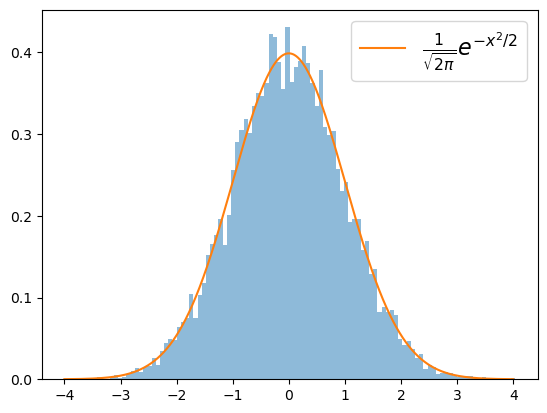

In [36]:
import matplotlib.pyplot as plt

sample = torch.randn(10_000)
plt.hist(sample.numpy(), 100, density=True, alpha=0.5)

x = np.linspace(-4, 4, 1000)
normal = (1 / np.sqrt(2 * np.pi)) * np.exp(-x ** 2 / 2)
plt.plot(x, normal, label=r'$\frac{1}{\sqrt{2 \pi}}e^{-x^2/2}$')
plt.legend(fontsize='16');

NumPy works the same way, with its own generator object:

In [37]:
from numpy.random import default_rng

rng = default_rng(42)              # 42 is the seed
print(rng.integers(1, 7, size=(10,)))
print(rng.standard_normal(size=(5,)))

[1 5 4 3 3 6 1 5 2 1]
[-1.30217951  0.1278404  -0.31624259 -0.01680116 -0.85304393]


### A note about randomness

There is something truly fundamental about the usefulness of random variables. Randomness has pratical value and we will see many examples of that during this course.  An example we will see later this semester is [stochastic gradient descent](https://en.wikipedia.org/wiki/Stochastic_gradient_descent), an example of an algorithm made better by randomness.

### Ranges

`arange` is the NumPy equivalent of the `range` function.  It is more flxible than its pure Python counterpart and provides fractional strides:

In [38]:
np.arange(2, 3, 0.1)

array([2. , 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9])

The `linspace` function provides similar functionality with a slightly different interface:

In [39]:
np.linspace(1., 4., 6)

array([1. , 1.6, 2.2, 2.8, 3.4, 4. ])

### Array indexing and slicing

Indexing in NumPy behaves like you would expect in Python:

In [40]:
a = np.array([2,3,4])
print("array elements:  ", a[0], a[1], a[2])
a[0] = 5                  # Change an element of the array
a

array elements:   2 3 4


array([5, 3, 4])

Similarly to Python lists, you can use negative numbers to index NumPy arrays.  For example `a[-1]` is the last element in an array:

In [41]:
a[-1]

np.int64(4)

### Class question

Can you explain what's happening in the following piece of code?  (Hint:  refer to the picture shown above of a NumPy array.)

In [42]:
a = np.array([2,3,4])
b = a
b[0] = 1234
print("a: ", a)
print("b: ", b)

a:  [1234    3    4]
b:  [1234    3    4]


### Slices in NumPy

The syntax for slices in NumPy is the same as slices of Python lists:

In [43]:
a = np.arange(10)
print(a)
a[5:8]

[0 1 2 3 4 5 6 7 8 9]


array([5, 6, 7])

You can assign values to a slice:

In [44]:
a[5:8] = 12
a

array([ 0,  1,  2,  3,  4, 12, 12, 12,  8,  9])

Do slices create copies of the underlying data?  Let's see:

In [45]:
a_slice = a[5:8]
a_slice

array([12, 12, 12])

In [46]:
a_slice[1] = 12345
a

array([    0,     1,     2,     3,     4,    12, 12345,    12,     8,
           9])

NumPy has been designed to be able to work with very large arrays, so eagerly copying data could cause severe performance and memory problems.

If you want a copy of a slice instead of a view, you will need to explicitly copy it using e.g. ``arr[5:8].copy()``.


### Two dimensional arrays

Let's look at two dimensional arrays or *matrices*.

In [47]:
a = np.array([[1,2,3,4], [5,6,7,8], [9,10,11,12]])

# two ways of indexing a two dimensional array:
print(a[0, 0], a[0, 1])
print(a[0][0], a[0][1])

a.shape

1 2
1 2


(3, 4)

The latter form of indexing works, because each row of a two dimensional array is an array as well.

So, to access the first row:

In [48]:
row = a[0]    # the first row of a
row, row.shape

(array([1, 2, 3, 4]), (4,))

In [49]:
a[0]

array([1, 2, 3, 4])

To access a column:

In [50]:
print(a)
col = a[:, 0]
col, col.shape

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]


(array([1, 5, 9]), (3,))

We can perform slicing on multiple dimensions, creating a submatrix:

In [51]:
print(f'a:\n{a}')
submatrix = a[1:3, 1:4]
print(f'submatrix:\n{submatrix}')
submatrix.shape

a:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
submatrix:
[[ 6  7  8]
 [10 11 12]]


(2, 3)

### Fancy indexing

You can index an array using an integer array:


In [52]:
a

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [53]:
print(f'a: \n{a}')
a[ [0, 2] ]   # extract a given set of rows

a: 
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]


array([[ 1,  2,  3,  4],
       [ 9, 10, 11, 12]])

In [54]:
a[:, [0,2]]  # extract a given set of columns

array([[ 1,  3],
       [ 5,  7],
       [ 9, 11]])

This is called **fancy indexing**.

Works the same in PyTorch:

In [55]:
b = torch.tensor([[1,2,3,4], [5,6,7,8], [9,10,11,12]])
b[ [0,2] ]

tensor([[ 1,  2,  3,  4],
        [ 9, 10, 11, 12]])

In [56]:
b[:, [0,2]]

tensor([[ 1,  3],
        [ 5,  7],
        [ 9, 11]])

### Question

**Question:** does fancy indexing create a copy of the array or simply a view, as in the case of slicing?

In [57]:
## write some code to answer this question

### Exercises

Describe the effect of each of the following slices:

In [58]:
a2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
a2d

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [59]:
a2d[:2]

array([[1, 2, 3],
       [4, 5, 6]])

In [60]:
a2d[:2, 1:]

array([[2, 3],
       [5, 6]])

In [61]:
a2d[-1]

array([7, 8, 9])

In [62]:
a2d[-1, :2]

array([7, 8])

In [63]:
a2d[:, :]

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

### Boolean indexing

You are about to see another very powerful aspect of arrays in NumPy:
 selectively accessing parts of an array based on a Boolean condition.
This is called **Boolean indexing**.

In [64]:
names = np.array(['Bob', 'Joe', 'Will', 'Bob', 'Will', 'Joe', 'Joe'])
data = rng.standard_normal(size=(7, 4))
print(f'Names are:\n{names}')
print(f'Data is:\n{data}')

Names are:
['Bob' 'Joe' 'Will' 'Bob' 'Will' 'Joe' 'Joe']
Data is:
[[ 0.87939797  0.77779194  0.0660307   1.12724121]
 [ 0.46750934 -0.85929246  0.36875078 -0.9588826 ]
 [ 0.8784503  -0.04992591 -0.18486236 -0.68092954]
 [ 1.22254134 -0.15452948 -0.42832782 -0.35213355]
 [ 0.53230919  0.36544406  0.41273261  0.430821  ]
 [ 2.1416476  -0.40641502 -0.51224273 -0.81377273]
 [ 0.61597942  1.12897229 -0.11394746 -0.84015648]]


In [65]:
names == 'Bob'

array([ True, False, False,  True, False, False, False])

In [66]:
data[names == 'Bob']

array([[ 0.87939797,  0.77779194,  0.0660307 ,  1.12724121],
       [ 1.22254134, -0.15452948, -0.42832782, -0.35213355]])

In [67]:
cond = names == 'Bob'
print(~cond)
data[~cond]

[False  True  True False  True  True  True]


array([[ 0.46750934, -0.85929246,  0.36875078, -0.9588826 ],
       [ 0.8784503 , -0.04992591, -0.18486236, -0.68092954],
       [ 0.53230919,  0.36544406,  0.41273261,  0.430821  ],
       [ 2.1416476 , -0.40641502, -0.51224273, -0.81377273],
       [ 0.61597942,  1.12897229, -0.11394746, -0.84015648]])

In [68]:
cond = (names == 'Bob') | (names == 'Will')
print(cond)
data[cond]

[ True False  True  True  True False False]


array([[ 0.87939797,  0.77779194,  0.0660307 ,  1.12724121],
       [ 0.8784503 , -0.04992591, -0.18486236, -0.68092954],
       [ 1.22254134, -0.15452948, -0.42832782, -0.35213355],
       [ 0.53230919,  0.36544406,  0.41273261,  0.430821  ]])

**Note:** The Python keywords ``and`` and ``or`` do not work with boolean arrays. You need to use the operators & and | instead of `and` / `or`, as you have just seen above.

We can use conditions to modify an array:

In [69]:
print(data < 0)
data[data < 0] = 0
data

[[False False False False]
 [False  True False  True]
 [False  True  True  True]
 [False  True  True  True]
 [False False False False]
 [False  True  True  True]
 [False False  True  True]]


array([[0.87939797, 0.77779194, 0.0660307 , 1.12724121],
       [0.46750934, 0.        , 0.36875078, 0.        ],
       [0.8784503 , 0.        , 0.        , 0.        ],
       [1.22254134, 0.        , 0.        , 0.        ],
       [0.53230919, 0.36544406, 0.41273261, 0.430821  ],
       [2.1416476 , 0.        , 0.        , 0.        ],
       [0.61597942, 1.12897229, 0.        , 0.        ]])

In [70]:
data[names != 'Joe'] = 7
data

array([[7.        , 7.        , 7.        , 7.        ],
       [0.46750934, 0.        , 0.36875078, 0.        ],
       [7.        , 7.        , 7.        , 7.        ],
       [7.        , 7.        , 7.        , 7.        ],
       [7.        , 7.        , 7.        , 7.        ],
       [2.1416476 , 0.        , 0.        , 0.        ],
       [0.61597942, 1.12897229, 0.        , 0.        ]])

In [71]:
data = torch.normal(0, 1, size=(7, 4))
data

tensor([[ 0.2472,  1.1692, -0.3546,  1.0278],
        [-0.0959, -0.6737,  0.0118, -0.5150],
        [ 1.5781,  1.1301,  0.3552,  0.4259],
        [ 0.7622, -0.1894,  0.0621,  0.2685],
        [ 0.6053,  0.0412, -2.1424, -0.7930],
        [ 1.3394,  1.2698, -0.4576,  0.6375],
        [ 0.3438,  0.0418, -1.7697,  0.1025]])

In [72]:
print(data < 0)
data[data < 0] = 0
data

tensor([[False, False,  True, False],
        [ True,  True, False,  True],
        [False, False, False, False],
        [False,  True, False, False],
        [False, False,  True,  True],
        [False, False,  True, False],
        [False, False,  True, False]])


tensor([[0.2472, 1.1692, 0.0000, 1.0278],
        [0.0000, 0.0000, 0.0118, 0.0000],
        [1.5781, 1.1301, 0.3552, 0.4259],
        [0.7622, 0.0000, 0.0621, 0.2685],
        [0.6053, 0.0412, 0.0000, 0.0000],
        [1.3394, 1.2698, 0.0000, 0.6375],
        [0.3438, 0.0418, 0.0000, 0.1025]])

### Reshaping arrays

You can modify the shape of an array as long as you maintain the number of elements:

In [73]:
a = np.arange(15)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [74]:
a = np.arange(15).reshape((3, 5))
(a,a.shape)

(array([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14]]),
 (3, 5))

Here's where it becomes interesting - instead of performing reshape as we have done above:

In [75]:
np.arange(15).reshape((3, 5))

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

we can do the following:

In [76]:
np.arange(15).reshape((-1, 5))

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

This is a neat trick:  -1 here means "as many rows as needed".

In [77]:
torch.arange(15).reshape((-1, 5))

tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14]])

### Universal Functions: Fast Element-Wise Array Functions

A universal function, or *ufunc*, is a function that performs element-wise operations on data in an ndarray. 


In [78]:
a = np.arange(5)
np.set_printoptions(precision=3)
print(f'array:\t\t{a}')
print(f'Square root:\t{np.sqrt(a)}')
print(f'Exponentiate:\t{np.exp(a)}')
print(f'Square:\t\t{np.square(a)}')

array:		[0 1 2 3 4]
Square root:	[0.    1.    1.414 1.732 2.   ]
Exponentiate:	[ 1.     2.718  7.389 20.086 54.598]
Square:		[ 0  1  4  9 16]


In the above code we controlled the number of digits displayed.  That does not affect the precision of computations!  Also notice the use of the tab character and resulting alignment of the printed output.

A complete list of ufuncs is available in the [NumPy documentation](https://docs.scipy.org/doc/numpy/reference/ufuncs.html#available-ufuncs).

### Stacking arrays

You can extend arrays by stacking them horizontally or vertically:

In [79]:
x = np.array( [[1,2],[3,4]] )
y = np.array( [[5,6],[7,8]] )
np.vstack([x,y]),np.hstack([x,y])

(array([[1, 2],
        [3, 4],
        [5, 6],
        [7, 8]]),
 array([[1, 2, 5, 6],
        [3, 4, 7, 8]]))

In machine learning vertical and horizontal stacking of arrays is used to add features or training examples to a feature matrix $X$.  There are other forms of stacking arrays, and we refer your to the NumPy documentation for [additional stacking functions](https://numpy.org/doc/stable/reference/routines.array-manipulation.html#joining-arrays).

In [80]:
x = torch.tensor( [[1,2],[3,4]] )
y = torch.tensor( [[5,6],[7,8]] )
torch.vstack([x,y]),torch.hstack([x,y])

(tensor([[1, 2],
         [3, 4],
         [5, 6],
         [7, 8]]),
 tensor([[1, 2, 5, 6],
         [3, 4, 7, 8]]))

PyTorch's general form of these is `torch.cat`, which joins tensors **along an
existing dimension**: `dim=0` reproduces `vstack` and `dim=1` reproduces
`hstack`.  Its close relative `torch.stack` instead places them side by side
**along a new dimension**.  Confusing?  Let's see some examples:

In [81]:
x = torch.tensor([[1, 2], [3, 4]])
y = torch.tensor([[5, 6], [7, 8]])

print('cat dim=0  ', tuple(torch.cat([x, y], dim=0).shape), ' — like vstack')
print('cat dim=1  ', tuple(torch.cat([x, y], dim=1).shape), ' — like hstack')
print('stack      ', tuple(torch.stack([x, y]).shape), ' — a new first dimension')
print(torch.stack([x, y]))

cat dim=0   (4, 2)  — like vstack
cat dim=1   (2, 4)  — like hstack
stack       (2, 2, 2)  — a new first dimension
tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])


`stack` is how a batch is built: give it $B$ images of shape $(3, 32, 32)$ and
it returns a single tensor of shape $(B, 3, 32, 32)$.

### Array Broadcasting

Consider the following piece of code:

In [82]:
x = np.array([[1,2,3], [4,5,6], [7,8,9], [10, 11, 12]])
v = np.array([1, 0, 1])
# Add the vector v to each row of the matrix x with an explicit loop
for i in range(len(x)) :
    x[i] = x[i] + v
x

array([[ 2,  2,  4],
       [ 5,  5,  7],
       [ 8,  8, 10],
       [11, 11, 13]])

There is a much more efficient way of doing this that does not use a loop:

In [83]:
x = np.array([[1,2,3], [4,5,6], [7,8,9], [10, 11, 12]])
v = np.array([1, 0, 1])
x + v

array([[ 2,  2,  4],
       [ 5,  5,  7],
       [ 8,  8, 10],
       [11, 11, 13]])

This is called **broadcasting**.
The following image explains what NumPy is doing in this case:

<img style="padding: 10px; float:center;" alt="broadcasting" src="https://numpy.org/doc/stable/_images/broadcasting_2.png" width="500">

Broadcasting is described in greater detail in the [NumPy documentation](https://numpy.org/doc/stable/user/basics.broadcasting.html) and [data science handbook](https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html).


### Adding and removing dimensions

Very often the numbers you have are the numbers you want, and only the shape is
wrong.  You have one image of shape $(3, 32, 32)$ and the model expects a batch,
$(B, 3, 32, 32)$.  You have three values and want them treated as a column, so
that they broadcast down the rows rather than across the columns.

`unsqueeze` inserts a dimension of length 1 at a position you choose, and
`squeeze` removes one.  Both are reshaping operations: the elements and their
order are untouched, and a dimension of length 1 holds no elements, so there is
nothing to move.

In [84]:
image = torch.randn(3, 32, 32)             # one RGB image
print(tuple(image.unsqueeze(0).shape))     # (1, 3, 32, 32): a batch of one

v = torch.tensor([1., 2., 3.])
print(tuple(v[:, None].shape), tuple(v[None, :].shape))   # column, row
print(v[:, None] * v[None, :])             # (3,1) * (1,3) -> the outer product

(1, 3, 32, 32)
(3, 1) (1, 3)
tensor([[1., 2., 3.],
        [2., 4., 6.],
        [3., 6., 9.]])


Indexing with `None` is the same operation written more succinctly, and you
will meet both.  Going the other way, `squeeze` clears away the length-1
dimensions that reductions and indexing leave behind:

In [85]:
scores = torch.randn(4, 1)                 # one score per example
print(tuple(scores.squeeze(1).shape))      # (4,)

(4,)


Give `squeeze` a dimension when you can.  Bare `squeeze()` removes *every*
dimension of length 1, which is fine until the day your batch happens to
contain a single example and the batch dimension quietly disappears with it.

### Mathematical  and statistical operations on arrays

NumPy provides functionality for a variety of mathematical operations on arrays:

* `np.sum` - sum
* `np.mean` - arithmetic mean
* `np.std` - standard deviation
* `np.median` - median
* `np.max`, `np.min` - maximum/minimum
* `np.argmax`, `np.argmin` - index of maximum/minimum

And many [more](https://numpy.org/doc/stable/reference/routines.statistics.html).

Applying these methods to a two dimensional array performs the operation over the entire array.  Let's look at `np.sum` for example:

In [86]:
a = rng.standard_normal(size=(4, 3))
print(a)
a.sum() # same as np.sum(a) 

[[-0.824  0.651  0.743]
 [ 0.543 -0.666  0.232]
 [ 0.117  0.219  0.871]
 [ 0.224  0.679  0.068]]


np.float64(2.856062992573524)

Sums can be performed along a given axis:

In [87]:
print(a)
a.sum(axis=0)

[[-0.824  0.651  0.743]
 [ 0.543 -0.666  0.232]
 [ 0.117  0.219  0.871]
 [ 0.224  0.679  0.068]]


array([0.059, 0.883, 1.914])

In [88]:
a[:, 0].sum()

np.float64(0.058954410529365925)

This can seem a bit confusing, but think about the axis keyword as determining the axis that collapses as a result of performing the operation.  It's NOT the axis over which the operation is performed!

In [89]:
a.sum(axis=1)

array([0.569, 0.11 , 1.207, 0.97 ])

In [90]:
a[0].sum()

np.float64(0.5693657433369038)

Let's demonstrate just how much faster the NumPy `sum` function is than its pure Python counterpart:

In [91]:
big_array = rng.random(size=(1000000,))
big_list = list(big_array)
%timeit sum(big_list)
%timeit np.sum(big_array)

22.6 ms ± 665 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
178 µs ± 1.05 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


The same in PyTorch:

In [92]:
a = torch.normal(0, 1, size=(4, 3))
print(a)
a.sum(axis=0)

tensor([[ 1.2312,  0.0267, -0.1156],
        [-0.8360, -0.4628, -1.1794],
        [-0.0112, -1.7139, -1.9011],
        [-1.3774, -0.2795, -0.2178]])


tensor([-0.9934, -2.4295, -3.4140])

In [93]:
a.sum(axis=1)

tensor([ 1.1423, -2.4782, -3.6262, -1.8747])

### NumPy and PyTorch for expressing mathematical formulas

One of the great advantages of using NumPy is that many of the mathematical formulas that are common in machine learning can be succinctly expressed.  Consider for example the computation of the mean-squared error which is used to quantify the quality of a regression model:

$$
\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^n (\hat{y}_i - y_i)^2.
$$

Here $y_1,\ldots,y_n$ are the given labels and $\hat{y}_1,\ldots,\hat{y}_n$ are the predicted labels.
The MSE quantifies the discrepancy between the predicted labels and the labels provided by the user.

This formula is easy to express using a single line of code:

In [94]:
y = np.array([1, 1.5, 2])
y_pred = np.array([0.8, 1.6, 2.4])

(1/len(y)) * np.sum( (y_pred - y)**2 )

# alternative:  (1/len(y)) * np.sum( np.square(y - y_pred))
# or:
# np.mean((y_pred - y)**2)

np.float64(0.06999999999999997)

### Exercise

* Compute the accuracy of a machine learning classifier.  In this case the labels are discrete, and the error is expressed as:
$$
\mathrm{accuracy} = \frac{1}{N}\sum_{i=1}^N \left[\hat{y}_i = y_i\right].
$$
Here the notation $[\mathrm{condition}]$ is the [Iverson bracket](https://en.wikipedia.org/wiki/Iverson_bracket), which is equal to 1 if the condition is true, and 0 otherwise.
Also note that the equality sign in this formula corresponds to the programming `==` operator.

In [95]:
y = np.array([0, 1, 1, 1, 0])
y_pred = np.array([1, 0, 1, 1, 0])
# as a hint consider the Boolean condition y==y_pred
# accuracy = ...

For your reference here is a pure Python implementation:

In [96]:
accuracy = sum([ y[i]==y_pred[i] for i in range(len(y)) ]) / len(y)
accuracy

np.float64(0.6)

### Reductions along a dimension

NumPy calls it `axis`; PyTorch calls it `dim`.  (PyTorch accepts `axis` as an
alias, but every notebook in this course writes `dim`, and so does every
PyTorch example you will find online.)  The meaning is the same: the dimension
that gets *collapsed*.

In [97]:
a = torch.arange(12, dtype=torch.float32).reshape(4, 3)
print(a)
print('a.sum(dim=0)', a.sum(dim=0), 'shape', a.sum(dim=0).shape)   # over rows
print('a.sum(dim=1)', a.sum(dim=1), 'shape', a.sum(dim=1).shape)   # over columns

tensor([[ 0.,  1.,  2.],
        [ 3.,  4.,  5.],
        [ 6.,  7.,  8.],
        [ 9., 10., 11.]])
a.sum(dim=0) tensor([18., 22., 26.]) shape torch.Size([3])
a.sum(dim=1) tensor([ 3., 12., 21., 30.]) shape torch.Size([4])


Reducing removes the dimension, which is inconvenient when you want to use the
result to adjust the original — the shapes no longer line up.  `keepdim=True`
leaves a length-1 dimension in its place — the same dimension `unsqueeze`
inserts — so broadcasting does the rest.  This
is how row-wise normalization is written:

In [98]:
row_max = a.max(dim=1, keepdim=True).values
print('row_max shape', row_max.shape)
print(a - row_max)                        # broadcasts over the columns

row_max shape torch.Size([4, 1])
tensor([[-2., -1.,  0.],
        [-2., -1.,  0.],
        [-2., -1.,  0.],
        [-2., -1.,  0.]])


Note `.values` in that line.  Unlike NumPy, `torch.max` along a dimension
returns **both** the values and their positions, and you have to say which one
you want:

In [99]:
result = a.max(dim=1)
print(result.values)          # the largest entry of each row
print(result.indices)         # where it sits — same as a.argmax(dim=1)

values, indices = a.max(dim=1)    # unpacking works too
print(values, indices)

tensor([ 2.,  5.,  8., 11.])
tensor([2, 2, 2, 2])
tensor([ 2.,  5.,  8., 11.]) tensor([2, 2, 2, 2])


### Getting values back out

A tensor is not a Python number, and printing one shows it: `tensor(0.5023)`
rather than `0.5023`.  Three ways out, depending on what you want:

* `.item()` — a Python number, for a tensor holding exactly one value.  This is
  what training loops use to record a loss.
* `.tolist()` — nested Python lists, for a tensor of any shape.
* `.numpy()` — a NumPy array sharing the same memory, for matplotlib, pandas,
  scikit-learn and anything else that does not speak tensor.

In [100]:
loss = torch.tensor(0.5023)
print(loss, '->', loss.item())

values = torch.tensor([1.5, 2.5, 3.5])
print(values.tolist())
print(values.numpy())

tensor(0.5023) -> 0.5023000240325928
[1.5, 2.5, 3.5]
[1.5 2.5 3.5]


There is one catch - a tensor that is part of a gradient computation cannot
be handed to NumPy directly:

In [101]:
tracked = torch.tensor([1.5, 2.5, 3.5], requires_grad=True)

try:
    tracked.numpy()
except RuntimeError as error:
    print('RuntimeError:', error)

print(tracked.detach().numpy())      # detach() first: a tensor with no gradient history

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.
[1.5 2.5 3.5]


`.detach()` returns the same numbers with the gradient bookkeeping stripped off
(the next section explains what that bookkeeping is).  A tensor living on a GPU
has to be brought back to the CPU as well, which is why the full incantation,
seen in almost every PyTorch codebase, is

```python
array = tensor.detach().cpu().numpy()
```

Each piece answers one objection: `detach` for the gradient history, `cpu` for
the device, `numpy` for the type.

### Where the tensor lives: CPU and GPU

Every tensor sits on a **device**.  NumPy arrays are always in main memory;
tensors can be in main memory (`cpu`), on an NVIDIA GPU (`cuda`), 
or the GPU built into an Apple silicon Mac, reached through Apple's Metal Performance Shaders (`mps`). 
This is most of the reason PyTorch exists: the same code runs
on a GPU, where a matrix multiplication can be a hundred times faster.

Notebooks in this course open with a version of the following, which picks the
best device available and falls back to the CPU:

In [102]:
device = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available()
          else 'cpu')
print(f'Using {device} device')

made_there = torch.randn(3, device=device)     # created on the device
moved_there = torch.randn(3).to(device)        # created on the CPU, then moved
print(made_there.device, moved_there.device)

Using mps device
mps:0 mps:0


The rule to remember: **operands must live on the same device.** Mixing them
raises an error rather than moving anything silently, because a silent transfer
across the PCIe bus would be a performance bug hiding in plain sight.

In [103]:
on_cpu = torch.randn(3)

if device != 'cpu':
    try:
        on_cpu + made_there
    except RuntimeError as error:
        print('RuntimeError:', str(error)[:120])
else:
    print('only a CPU here, so nothing to collide with')

print((on_cpu.to(device) + made_there).device)     # move first, then add

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, mps:0 and cpu!
mps:0


### Gradients: the thing NumPy does not have

Training a model means computing the derivative of a loss with respect to every
parameter.  PyTorch does that for you.  Mark a tensor with `requires_grad=True`
and PyTorch records every operation applied to it, building a graph as it goes;
calling `.backward()` on the final scalar walks that graph backwards and
deposits the derivatives in each tensor's `.grad`.

Take $y = x^2$, whose derivative is $2x$:

In [104]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
y.backward()
print('dy/dx at x = 3:', x.grad.item(), '  (should be 2x = 6)')

dy/dx at x = 3: 6.0   (should be 2x = 6)


Two behaviours surprise people.

**Gradients accumulate.**  A second `backward()` call *adds* to `.grad` rather than
replacing it.  This is deliberate, since a parameter can receive gradient from several
places, but it means the slate has to be wiped between steps.  In real training
loops that is what `optimizer.zero_grad()` is for:

In [105]:
z = x ** 3
z.backward()
print('after a second backward:', x.grad.item(), '  (6 + 27, not 27)')

x.grad = None                       # the manual version of zero_grad()
(x ** 3).backward()
print('after clearing:', x.grad.item(), '  (3x^2 = 27)')

after a second backward: 33.0   (6 + 27, not 27)
after clearing: 27.0   (3x^2 = 27)


**Keeping track of gradient information is not free**, and outside of training we do not want it.  Anything
inside a `torch.no_grad()` block is computed without building a graph, which is faster and more memory efficient.
Evaluation loops and parameter updates are both wrapped in it:

In [106]:
print('tracked outside:', (x * 2).requires_grad)

with torch.no_grad():
    print('tracked inside: ', (x * 2).requires_grad)

tracked outside: True
tracked inside:  False


That is the whole of autograd from the outside: mark, compute, `.backward()`,
read `.grad`, clear it, and switch it off when you are not training.  The
mechanism behind it — the chain rule, applied to that graph — is the subject of
the backpropagation notebook later in the course.

### Similarities between NumPy and PyTorch

PyTorch offers a very similar API to NumPy:

| Concept                 | NumPy (`np.ndarray`)         | PyTorch (`torch.Tensor`)  | Notes                                                           |
| ----------------------- | ---------------------------- | ------------------------- | --------------------------------------------------------------- |
| **n-D array structure** | ✅                            | ✅                         | Both support arbitrary dimensions (`shape`, indexing, slicing). |
| **Data types**          | `dtype` property             | `dtype` property          | Similar set of types (float32, int64, etc.).                    |
| **Shape access**        | `.shape`                     | `.shape`                  | Works identically.                                              |
| **Indexing & slicing**  | Python-style                 | Python-style              | Fancy indexing, boolean masks, negative indices work similarly. |
| **Broadcasting**        | ✅                            | ✅                         | Same broadcasting rules as NumPy.                               |
| **Element-wise ops**    | `a + b`, `a * b`             | Same syntax               | Also includes broadcasting and ufunc-like behavior.             |
| **Reduction ops**       | `np.sum`, `np.mean`          | `torch.sum`, `torch.mean` | Same semantics.                                                 |
| **Datatype Conversion**          | `.astype()`                  | `.to(dtype)`              |                                             |
| **Interoperability**    | `torch.from_numpy(np_array)` | `.numpy()`                | Zero-copy conversion if on CPU.                                 |


### Key differences between NumPy and PyTorch

Here is a summary of the most important differences between what NumPy and PyTorch:

| Area                            | NumPy                             | PyTorch                                                                       | Why It Matters                                                               |
| ------------------------------- | --------------------------------- | ----------------------------------------------------------------------------- | ---------------------------------------------------------------------------- |
| **Device placement**            |  CPU                        | CPU **or** GPU (`.to('cuda')`)                                      | Key for accelerating deep learning computations.    |
| **Gradients**                   | No autograd                       | `.requires_grad=True` enables automatic differentiation                       | Core for deep learning; operations tracked in a computation graph.           |
| **Data type defaults**          | `float64`                         | `float32`                                                                     | High precision is not always important in ML!         |
| **Random number API**           | Everything in `np.random`                | `torch.rand`, `torch.randn`, etc.                                             | Different function names; PyTorch RNG state separate from NumPy.             |
| **Library scope**               | General-purpose numeric computing | Adds autodiff and GPU support                                         | PyTorch includes deep learning operations.            |
| **Serialization**               | `np.save`, `np.load`              | `torch.save`, `torch.load`                                                    | PyTorch uses Python’s pickle by default.                                     |
| **Interop with Python scalars** | Transparent                       | Mostly transparent, but `.item()` needed to get Python scalar from 0-D tensor | Helps prevent silent graph breaks in autograd.                               |
